Train Data Shape: (45532, 78)
Test Data Shape: (11383, 77)


,index,QaA,QaE,QbA,QbE,QcA,QcE,QdA,QdE,QeA,...,wr_04,wr_05,wr_06,wr_07,wr_08,wr_09,wr_10,wr_11,wr_12,wr_13
0,0,3.0,363,4.0,1370,5.0,997,1.0,1024,2.0,...,0,1,0,1,1,0,1,0,1,1
1,1,5.0,647,5.0,1313,3.0,3387,5.0,2969,1.0,...,1,1,0,1,1,0,1,0,1,1
2,2,4.0,1623,1.0,1480,1.0,1021,4.0,3374,5.0,...,1,1,0,1,1,1,1,0,1,1
3,3,3.0,504,3.0,2311,4.0,992,3.0,3245,1.0,...,0,0,0,0,1,0,1,0,1,1
4,4,1.0,927,1.0,707,5.0,556,2.0,1062,1.0,...,1,1,1,1,1,0,1,1,1,1


데이터 크기 : (45532, 92)
결측치 비율 :
openness         0.376351
tp05             0.352785
agreeableness    0.326671
conscientious    0.326078
neuroticism      0.314350
extraversion     0.303127
tp03             0.261970
tp07             0.222876
tp06             0.202209
tp09             0.199530
tp04             0.126768
tp02             0.126351
tp01             0.111262
tp08             0.078758
tp10             0.039796
education        0.011596
urban            0.007072
hand             0.003536
married          0.002043
engnat           0.001691
dtype: float64
              index           QaA           QaE           QbA           QbE  \
count  45532.000000  45532.000000  4.553200e+04  45532.000000  4.553200e+04   
mean   22765.500000      2.129535  9.453570e+02      2.904463  2.189589e+03   
std    13144.100565      1.196952  1.307565e+04      1.566142  3.351027e+04   
min        0.000000      1.000000  2.500000e+01      1.000000  2.500000e+01   
25%    11382.750000      1.000000  4.040

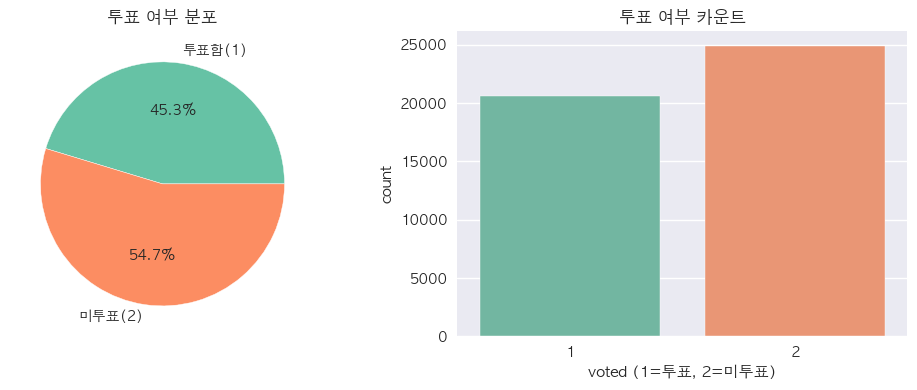

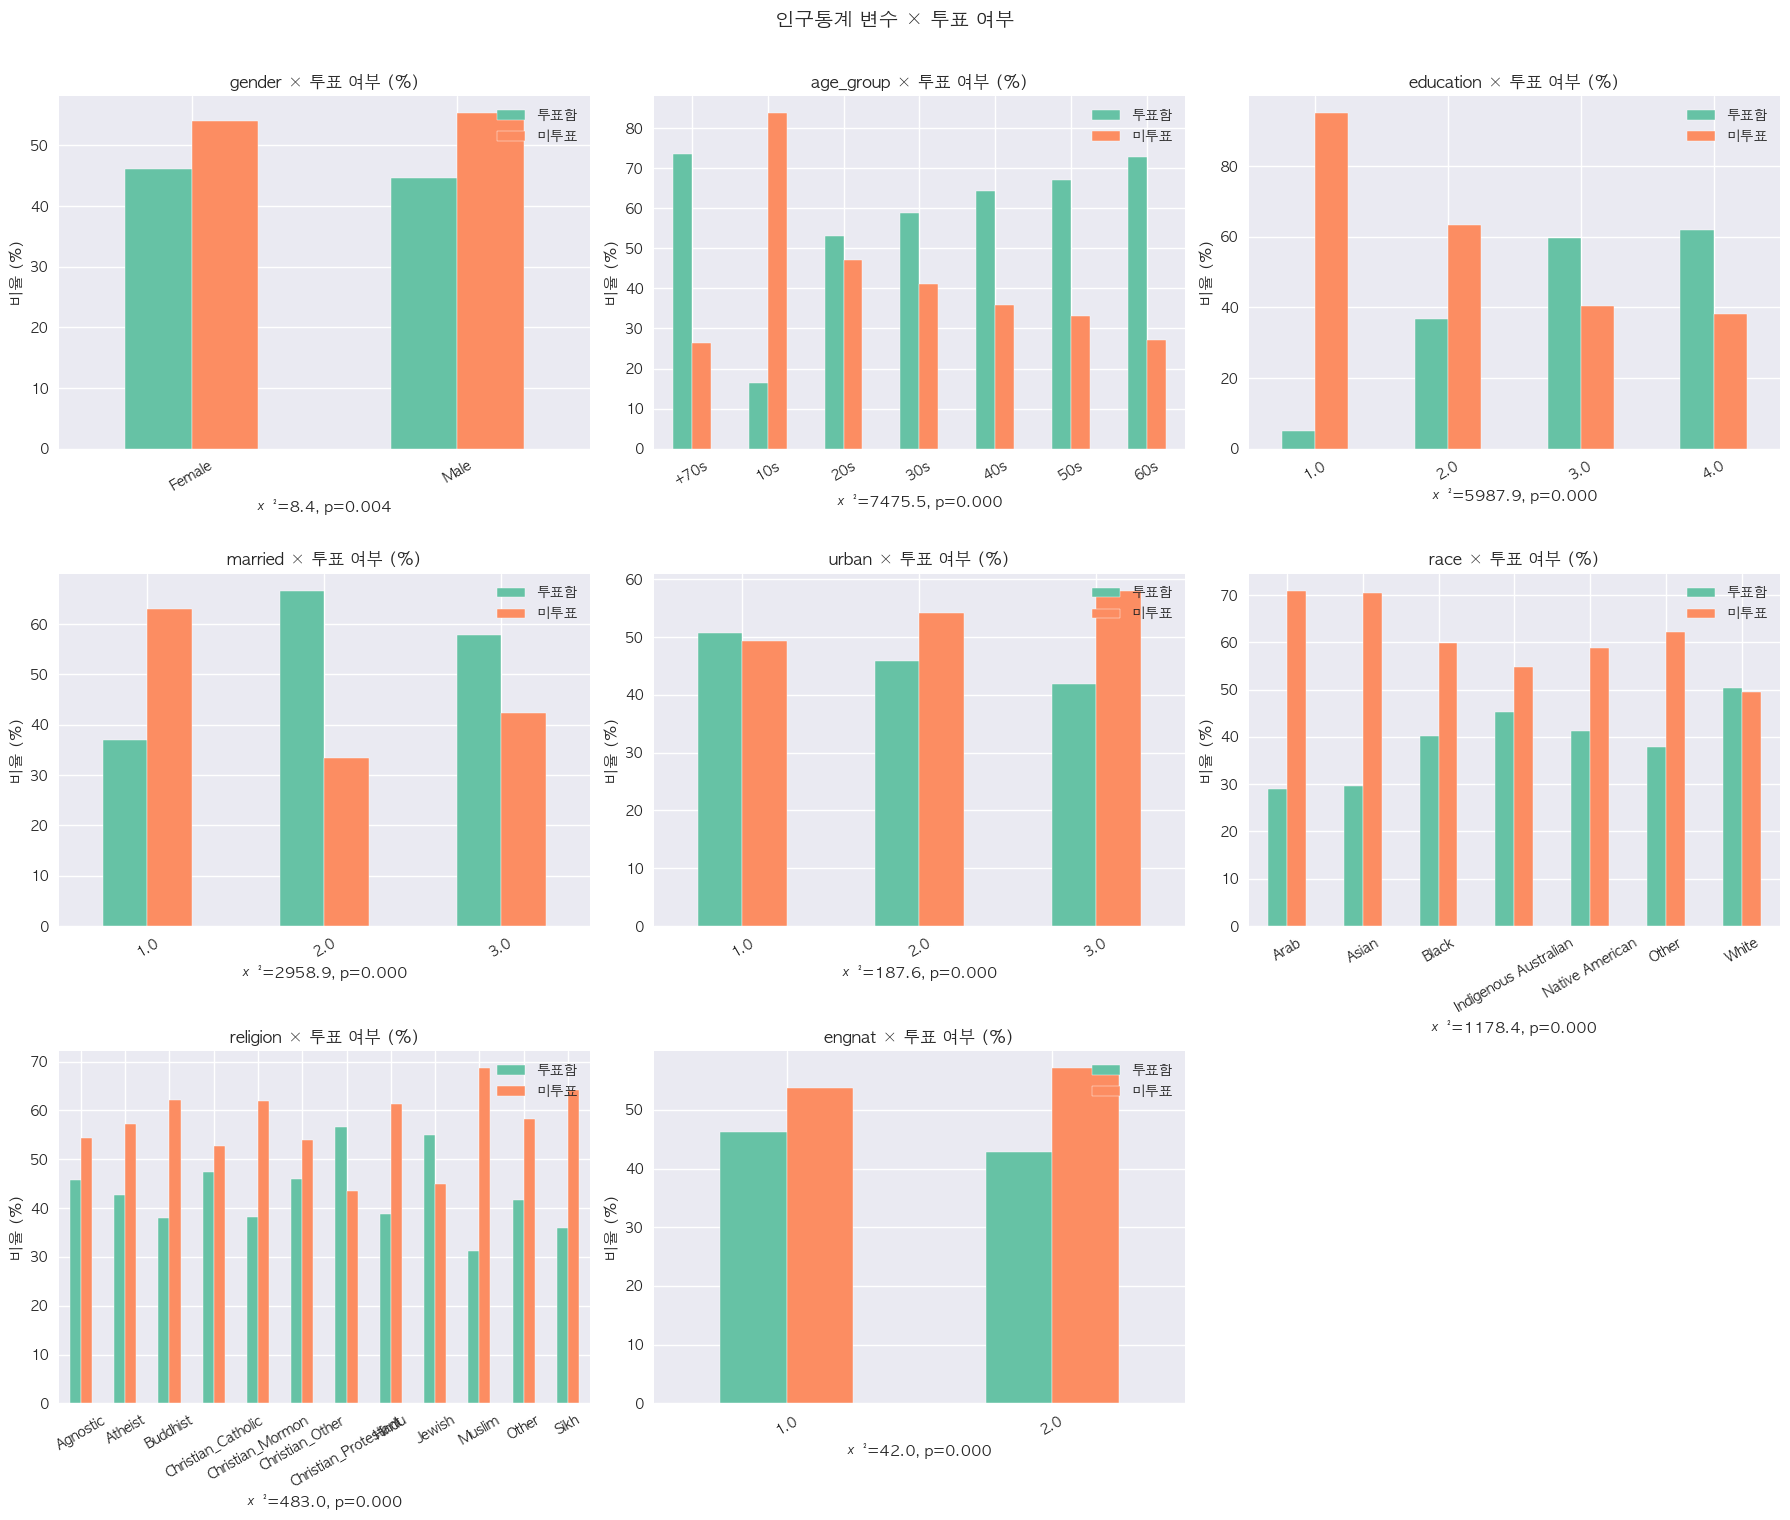

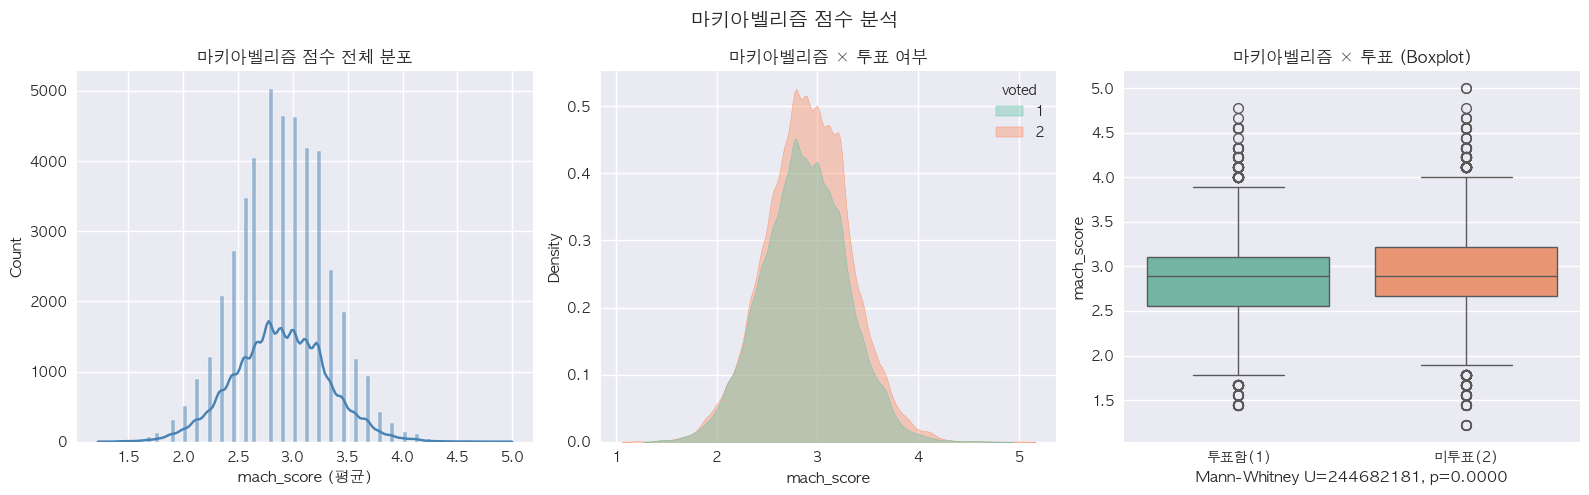

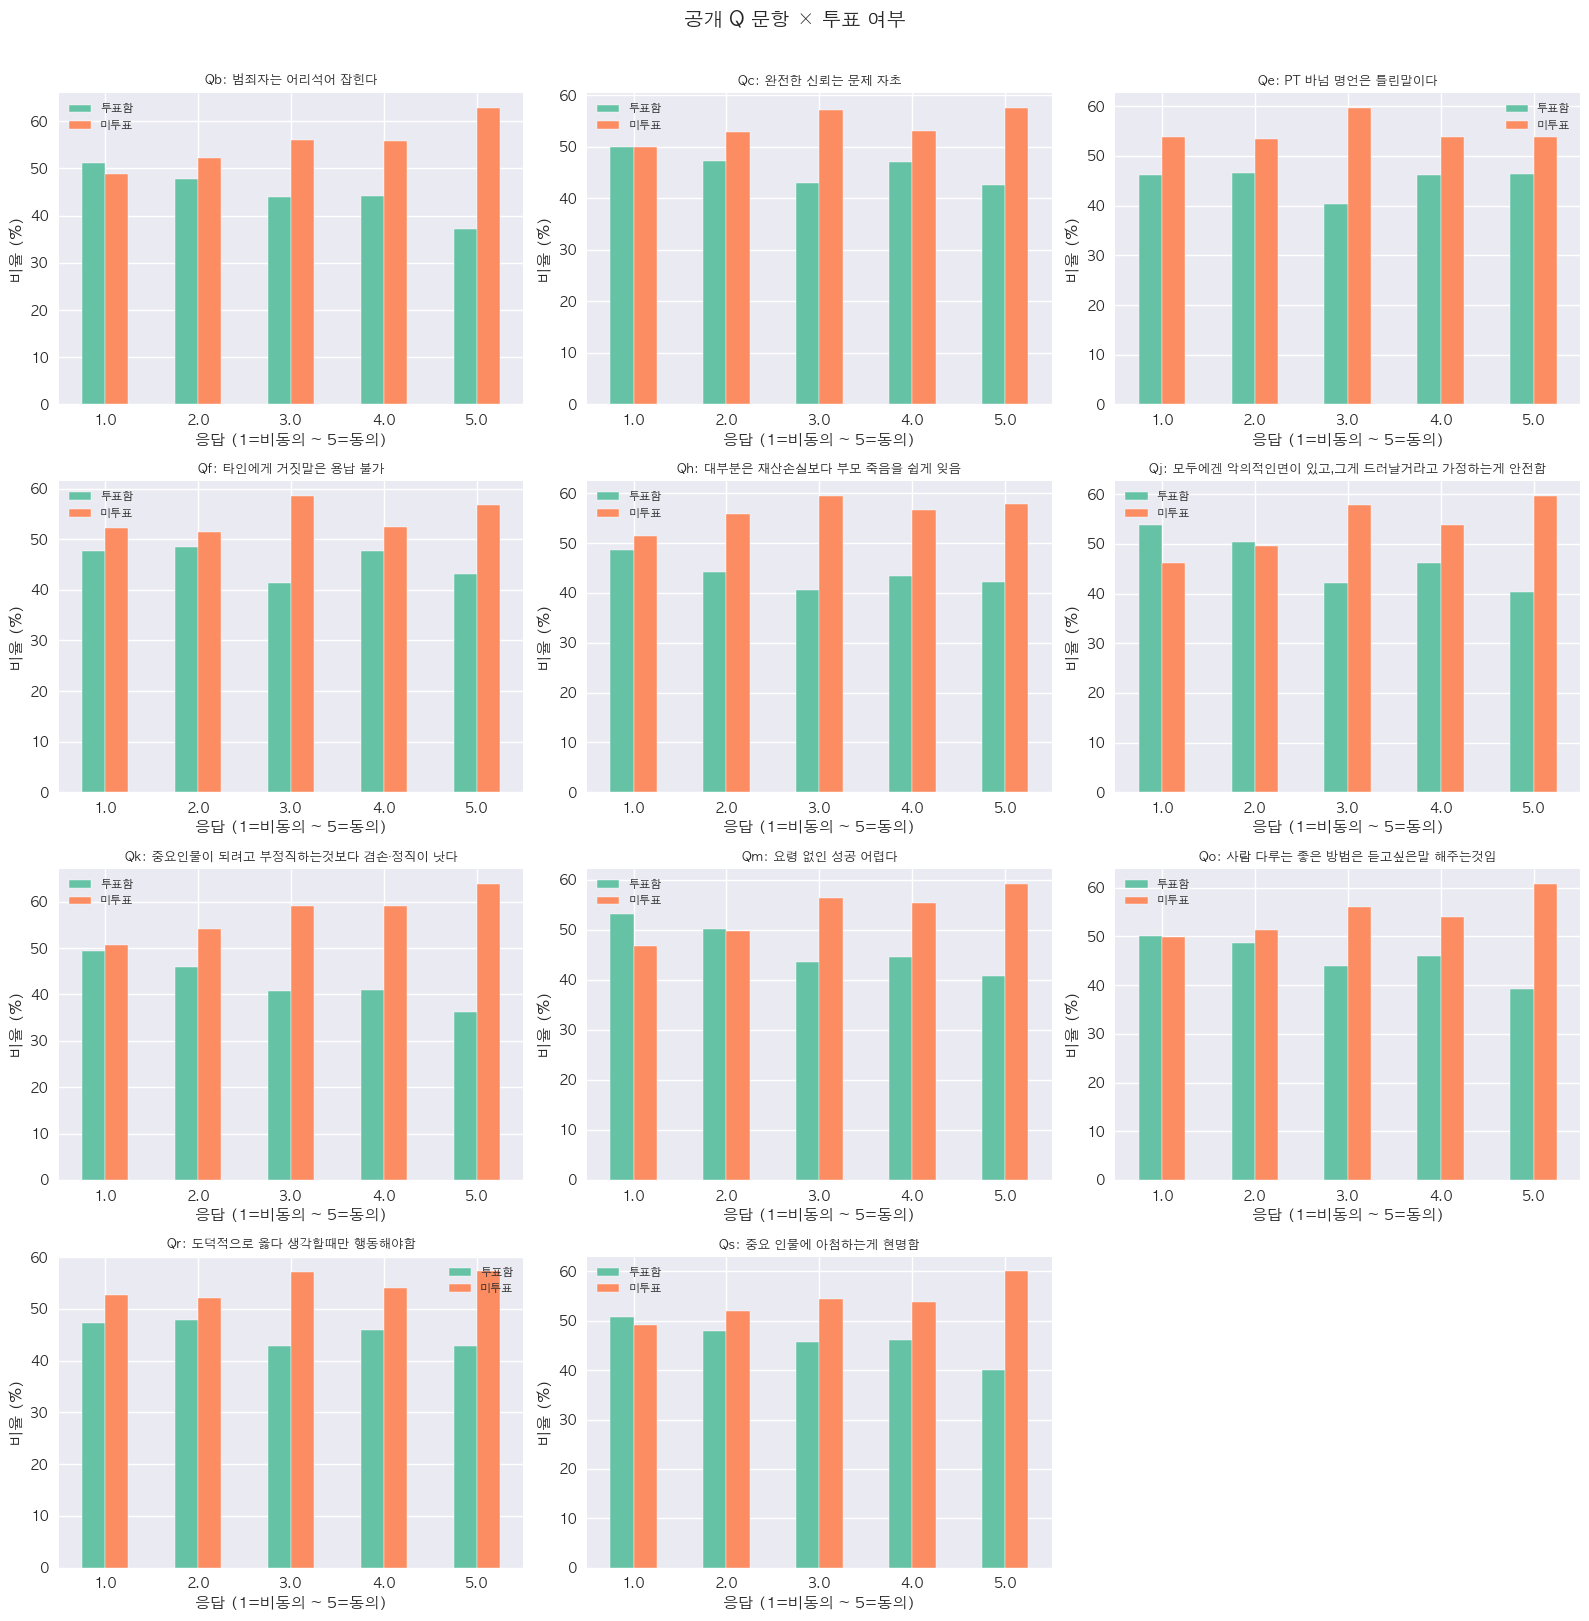

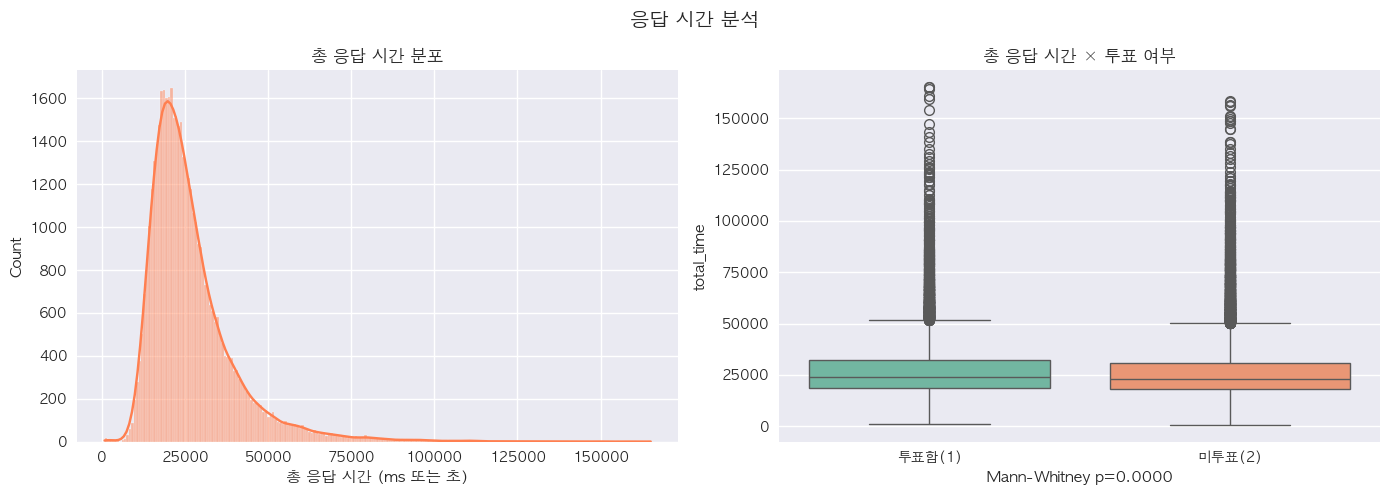

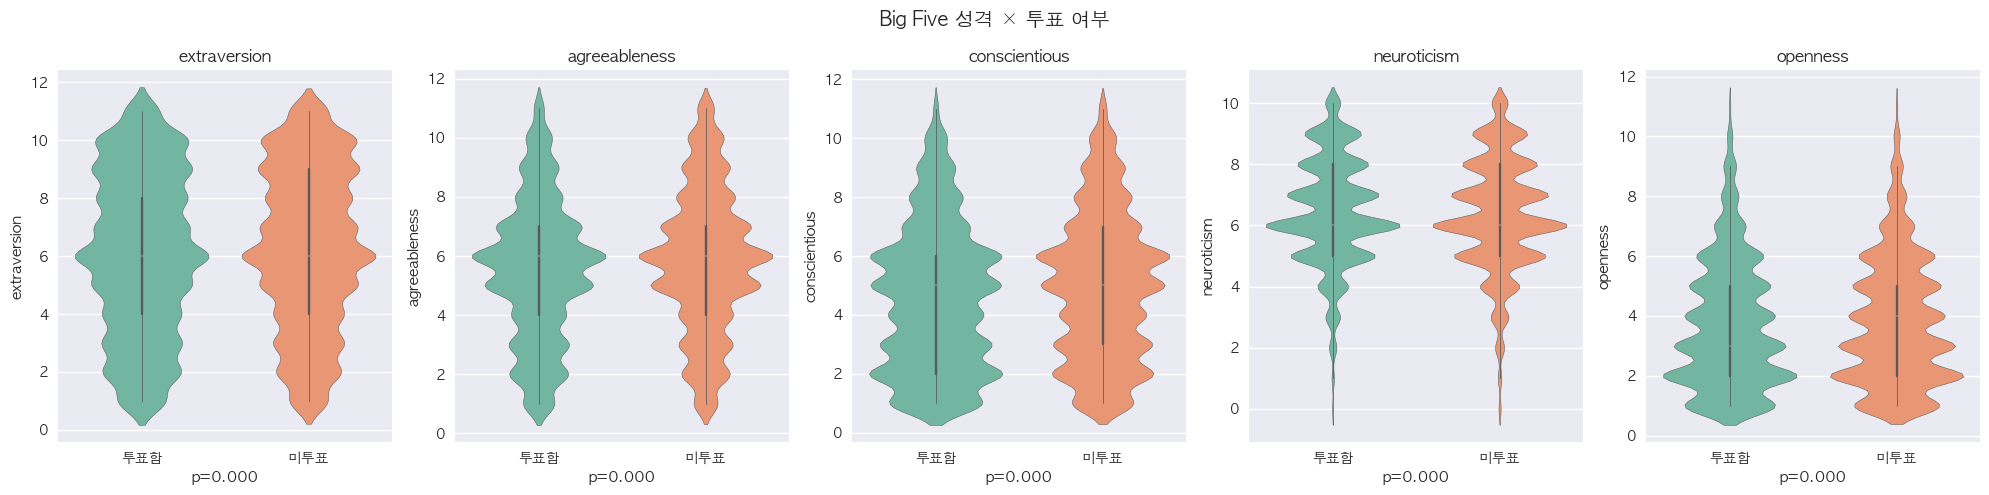

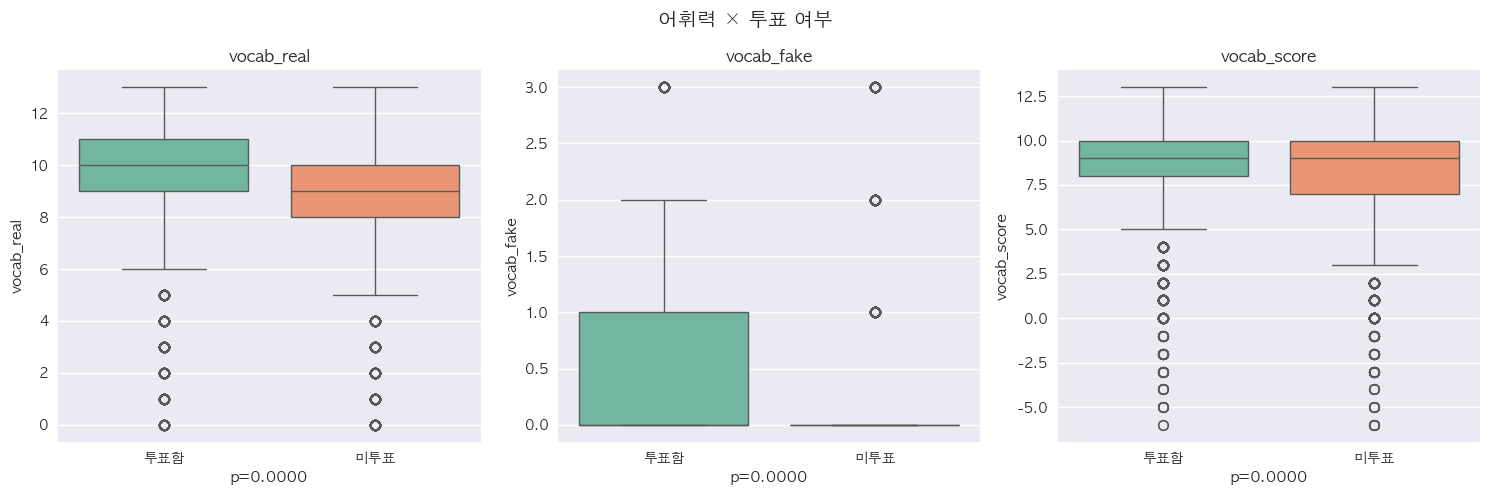

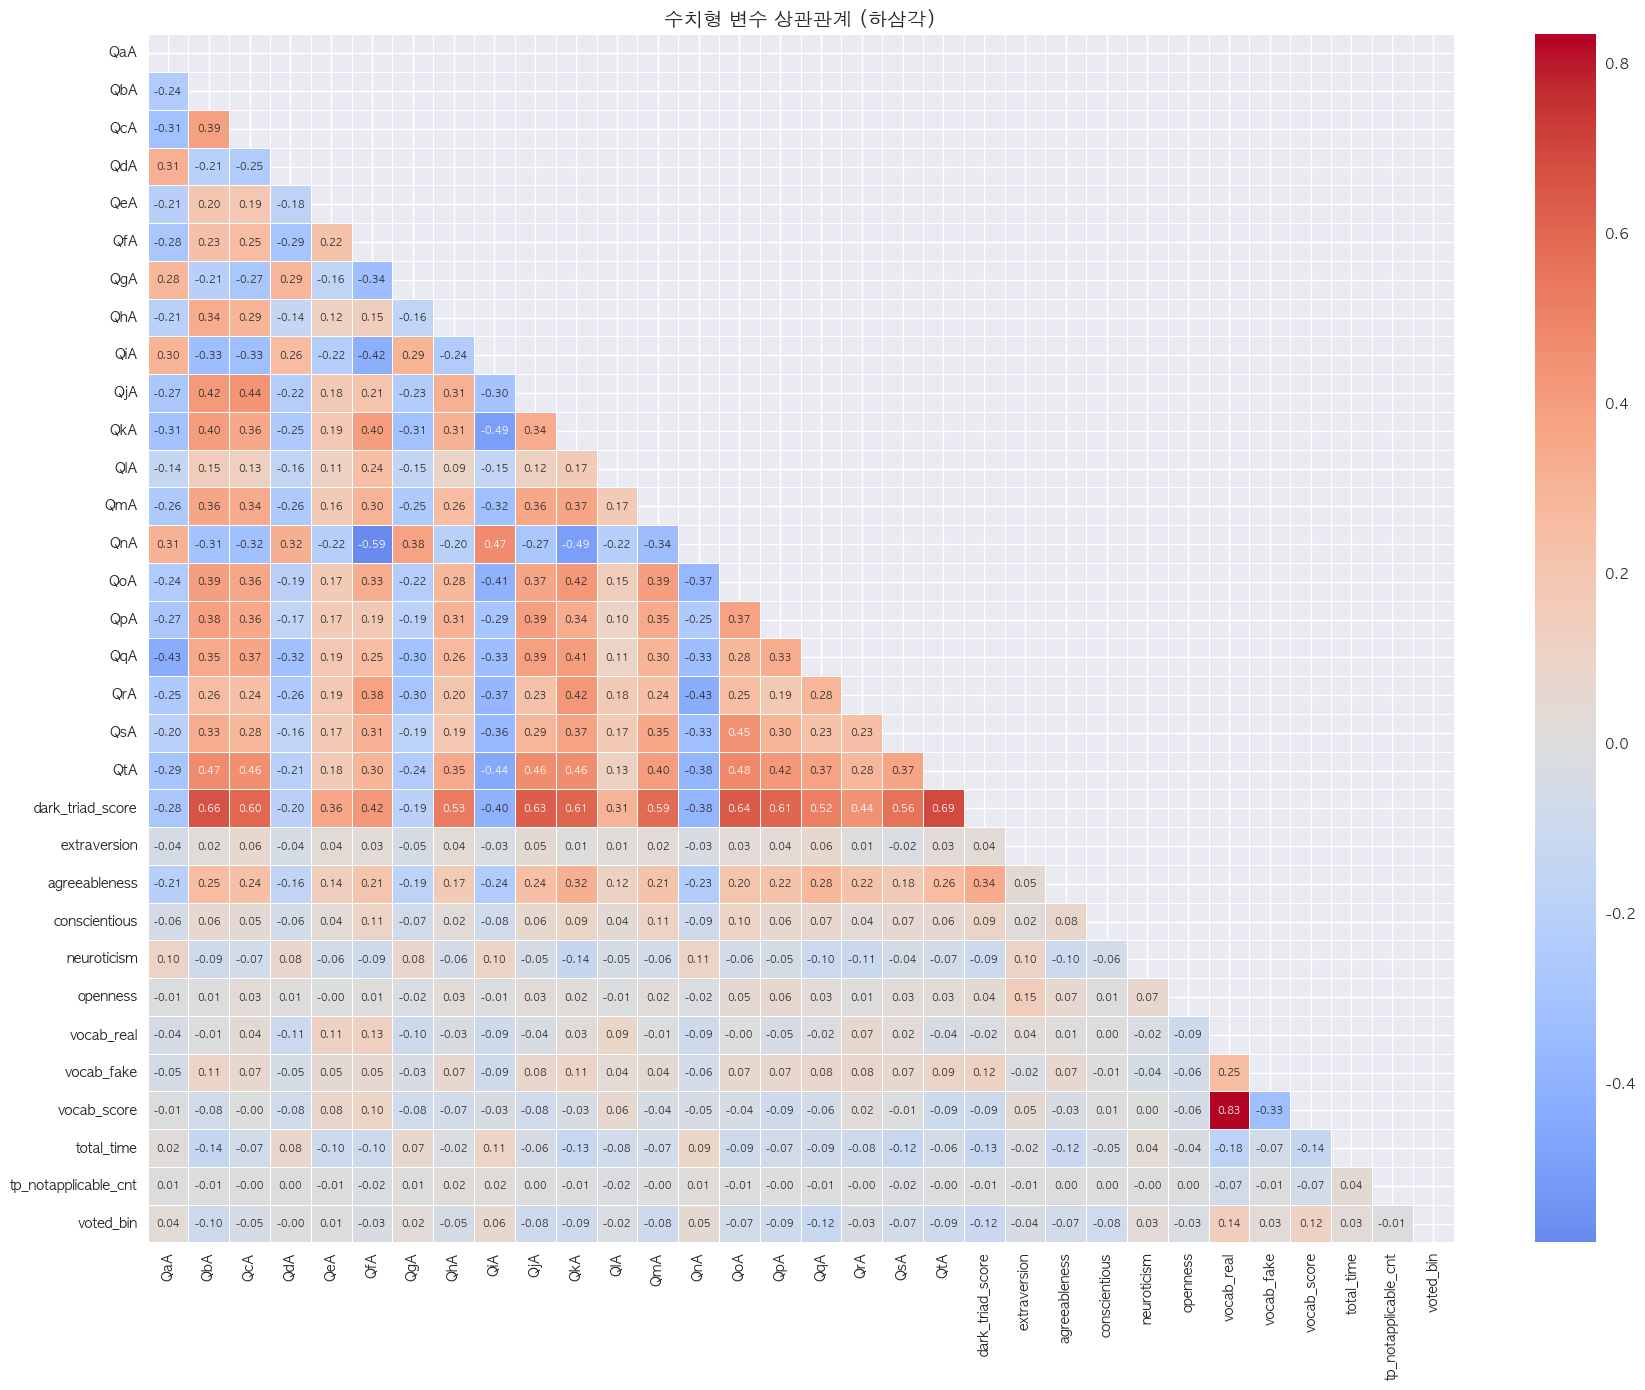

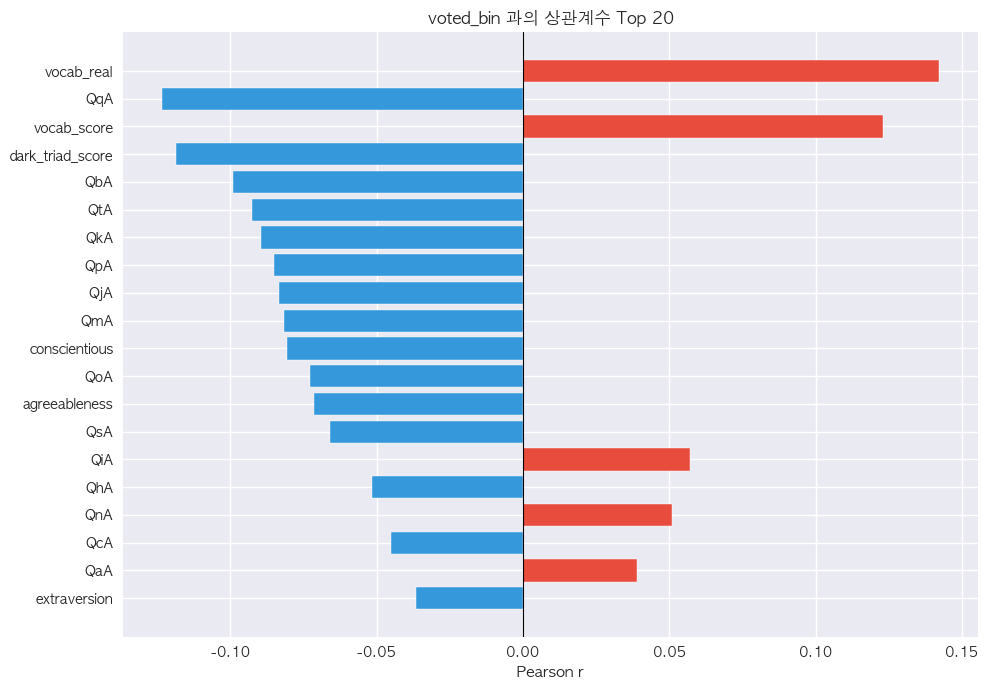

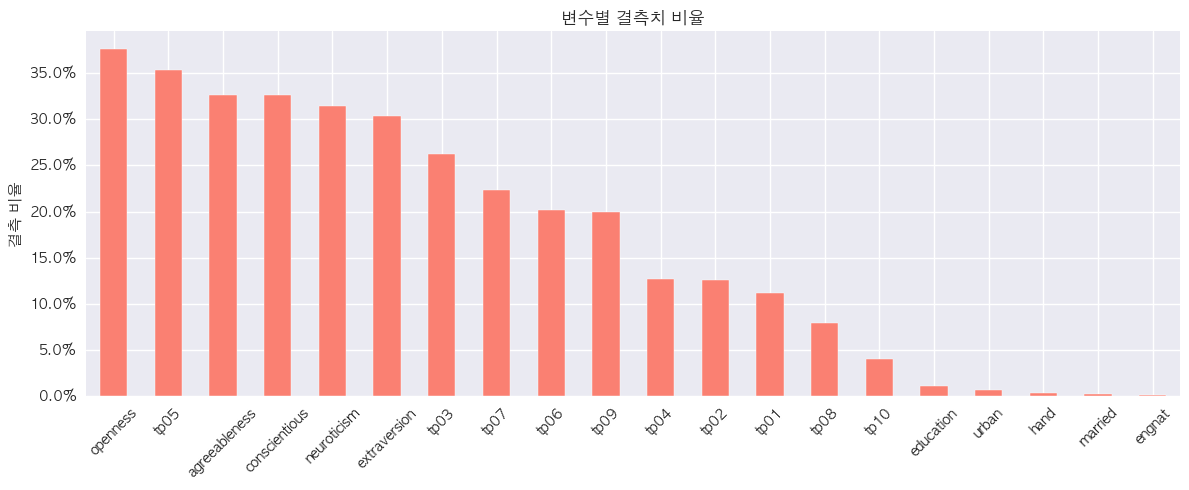


[투표 여부별 주요 수치 요약]
      mach_score               vocab_score               total_time                     extraversion               agreeableness               conscientious               neuroticism               openness              
            mean median    std        mean median    std       mean   median        std         mean median    std          mean median    std          mean median    std        mean median    std     mean median    std
voted                                                                                                                                                                                                                      
1          2.869  2.889  0.414       8.881    9.0  2.369  27388.171  24189.0  13274.137        6.078    6.0  2.803         5.489    6.0  2.382         4.584    5.0  2.458       6.443    6.0  1.760    3.739    3.0  2.125
2          2.904  2.889  0.420       8.282    9.0  2.436  26635.256  23242.5  13690.616        6.282 

In [36]:
# =============================================================
#   EDA — 투표 여부 예측 데이터셋
# =============================================================
#   Target  : voted  (1=투표함, 2=투표 안 함)
#   주요 그룹 : Q (마키아벨리즘 척도), 인구통계, tp(성격), wr/wf(어휘)
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu
import warnings

warnings.filterwarnings('ignore')

# 테마와 스타일 적용
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8') # 시각화 스타일 설정

# 한글폰트와 마이너스 깨짐 방지 덮어씌우기
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

PALETTE = "Set2"

# 데이터 로드
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test_x.csv")

# 데이터 구조 확인
print(f"Train Data Shape: {train.shape}")
print(f"Test Data Shape: {test.shape}")
display(train.head())

# ===================================================
# 변수 그룹 정의
# ===================================================
Q_COLS  = [f"Q{chr(ord('a')+i)}A" for i in range(20)]   # QaA ~ QtA 질문
QE_COLS = [f"Q{chr(ord('a')+i)}E" for i in range(20)]   # QaE ~ QtE 응답 시간
TP_COLS = [f"tp{str(i).zfill(2)}" for i in range(1, 11)]       # tp01~tp10
WR_COLS = [f"wr_{str(i).zfill(2)}" for i in range(1, 14)]      # wr_01~wr_13
WF_COLS = [f"wf_{str(i).zfill(2)}" for i in range(1, 4)]       # wf_01~wf_03
DEMO_COLS = ["age_group","education","engnat","familysize",
             "gender","hand","married","race","religion","urban"]

# ===================================================
# 전처리
# ===================================================
# "해당없음(7)" 응답 수를 별도 피처로 보존
tp_available_cols = [c for c in TP_COLS if c in train.columns]
train["tp_notapplicable_cnt"] = (train[tp_available_cols] == 7).sum(axis=1)

# tp 무응답(0), 해당없음(7) → NaN (수치 합산 계산을 위해)
for c in tp_available_cols:
    train[c] = train[c].replace({0: np.nan, 7: np.nan})
 
# 인구통계 무응답(0) → NaN
for c in ["education","engnat","hand","married","urban"]:
    if c in train.columns:
        train[c] = train[c].replace(0, np.nan)
 
# voted 이진화 (1=투표, 0=미투표)
train["voted_bin"] = (train["voted"] == 1).astype(int)
 
# Q 점수 합산 (리버스 문항 처리 필요 시 별도 지정)
# 높을수록 마키아벨리즘↓ (긍정적/윤리적 방향)인 문항
REVERSE_Q = [
            "QeA",  # "세상엔 매분마다 속기 쉬운 사람이 한 명씩 태어난다"고 말한 건 틀린 말
            "QfA",  # 거짓말 절대 불용
             "QkA",  # 겸손·정직이 낫다
             "QqA",  # 사람들은 기본적으로 선하다
             "QrA"]  # 도덕적 확신 후 행동
#             item11  item15  item17  item20
available_q = [c for c in Q_COLS if c in train.columns]
for c in REVERSE_Q:
    if c in train.columns:
        train[c] = 6 - train[c]                   # 1~5 척도 리버스

# 전체 점수
train["dark_triad_score"] = train[available_q].mean(axis=1)


train["mach_score"]  = train[mach_q].mean(axis=1)
train["narc_score"]  = train[narc_q].mean(axis=1)
train["psyc_score"]  = train[psyc_q].mean(axis=1)
train["dark_triad_score"] = train[available_q].mean(axis=1)
 
# tp 합산 → Big Five 방향 점수
# 외향성: tp01(+) tp06(-)  / 우호성: tp07(+) tp02(-)
# 성실성: tp03(+) tp08(-)  / 신경성: tp04(+) tp09(-)  / 개방성: tp05(+) tp10(-)
if all(c in train.columns for c in TP_COLS):
    train["extraversion"]  = train["tp01"] + (6 - train["tp06"])
    train["agreeableness"] = train["tp07"] + (6 - train["tp02"])
    train["conscientious"] = train["tp03"] + (6 - train["tp08"])
    train["neuroticism"]   = (6 - train["tp04"]) + (6 - train["tp09"])  # tp04, tp09 둘 다 -키
    train["openness"]      = train["tp05"] + (6 - train["tp10"])
 
# 어휘 점수
train["vocab_real"]  = train[[c for c in WR_COLS if c in train.columns]].sum(axis=1)
train["vocab_fake"]  = train[[c for c in WF_COLS if c in train.columns]].sum(axis=1)
train["vocab_score"] = train["vocab_real"] - train["vocab_fake"] * 2   # 허구 단어 패널티
 
# ===================================================
# 데이터 무결성 검사 (Integrty Check)
# ===================================================

# 결측치 및 데이터 타입 확인
print("=" * 60)
print(f"데이터 크기 : {train.shape}")
print(f"결측치 비율 :\n{train.isnull().mean().sort_values(ascending=False).head(20)}")
print("=" * 60)
print(train.describe())

# 중복 데이터 확인
print(f"Train 데이터 중복: {train.duplicated().sum()}")

# ===================================================
# 타겟 분포
# ===================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
voted_cnt = train["voted"].value_counts().sort_index()
axes[0].pie(voted_cnt, labels=["투표함(1)", "미투표(2)"],
            autopct="%1.1f%%", colors=sns.color_palette(PALETTE))
axes[0].set_title("투표 여부 분포")
 
sns.countplot(data=train, x="voted", palette=PALETTE, ax=axes[1])
axes[1].set_title("투표 여부 카운트")
axes[1].set_xlabel("voted (1=투표, 2=미투표)")
plt.tight_layout()
plt.savefig("images/01_target_distribution.png", dpi=150)
plt.show()

# ===================================================
# 인구통계 vs 투표 여부
# ===================================================
cat_demo = ["gender", "age_group", "education", "married",
            "urban", "race", "religion", "engnat"]
cat_demo = [c for c in cat_demo if c in train.columns]
 
n_cols = 3
n_rows = (len(cat_demo) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()
 
for i, col in enumerate(cat_demo):
    ct = pd.crosstab(train[col], train["voted"], normalize="index") * 100
    ct.columns = ["투표함", "미투표"]
    ct.plot(kind="bar", ax=axes[i], color=sns.color_palette(PALETTE)[:2],
            edgecolor="white")
    axes[i].set_title(f"{col} × 투표 여부 (%)")
    axes[i].set_ylabel("비율 (%)")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(loc="upper right")
 
    # 카이제곱 검정
    ct_abs = pd.crosstab(train[col].dropna(), train.loc[train[col].notna(), "voted"])
    if ct_abs.shape[0] > 1 and ct_abs.shape[1] > 1:
        chi2, p, _, _ = chi2_contingency(ct_abs)
        axes[i].set_xlabel(f"χ²={chi2:.1f}, p={p:.3f}")
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("인구통계 변수 × 투표 여부", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("images/02_demographics_vs_voted.png", dpi=150)
plt.show()


# ===================================================
# 마키아벨리즘 점수 분포
# ===================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# 전체 분포
sns.histplot(train["mach_score"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("마키아벨리즘 점수 전체 분포")
axes[0].set_xlabel("mach_score (평균)")
 
# 투표 여부별 분포
sns.kdeplot(data=train, x="mach_score", hue="voted",
            palette=PALETTE, fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title("마키아벨리즘 × 투표 여부")
 
# 박스플롯
sns.boxplot(data=train, x="voted", y="mach_score",
            hue="voted", palette=PALETTE, legend=False, ax=axes[2])
axes[2].set_title("마키아벨리즘 × 투표 (Boxplot)")
axes[2].set_xticklabels(["투표함(1)", "미투표(2)"])
 
# Mann-Whitney U 검정
voted_m   = train.loc[train["voted"]==1, "mach_score"].dropna()
novoted_m = train.loc[train["voted"]==2, "mach_score"].dropna()
u, p = mannwhitneyu(voted_m, novoted_m, alternative="two-sided")
axes[2].set_xlabel(f"Mann-Whitney U={u:.0f}, p={p:.4f}")
 
plt.suptitle("마키아벨리즘 점수 분석", fontsize=14)
plt.tight_layout()
plt.savefig("images/03_mach_score.png", dpi=150)
plt.show()


# ===================================================
# 개별 Q 문항 × 투표 여부
# ===================================================
public_q = [c for c in available_q if c not in
            ["QaA","QdA","QgA","QiA","QlA","QnA","QpA","QqA","QtA"]]  # 공개 문항만
 
fig, axes = plt.subplots(
    (len(public_q) + 2) // 3, 3,
    figsize=(16, ((len(public_q) + 2) // 3) * 4)
)
axes = axes.flatten()
 
Q_LABELS = {
    "QbA": "Qb: 범죄자는 어리석어 잡힌다",
    "QcA": "Qc: 완전한 신뢰는 문제 자초",
    "QeA": "Qe: PT 바넘 명언은 틀린말이다",
    "QfA": "Qf: 타인에게 거짓말은 용납 불가",
    "QhA": "Qh: 대부분은 재산손실보다 부모 죽음을 쉽게 잊음",
    "QjA": "Qj: 모두에겐 악의적인면이 있고,그게 드러날거라고 가정하는게 안전함",
    "QkA": "Qk: 중요인물이 되려고 부정직하는것보다 겸손·정직이 낫다",
    "QmA": "Qm: 요령 없인 성공 어렵다",
    "QoA": "Qo: 사람 다루는 좋은 방법은 듣고싶은말 해주는것임",
    "QqA": "Qq: 사람들은 기본적으로 선하다",
    "QrA": "Qr: 도덕적으로 옳다 생각할때만 행동해야함",
    "QsA": "Qs: 중요 인물에 아첨하는게 현명함",
}
 
for i, col in enumerate(public_q):
    label = Q_LABELS.get(col, col)
    ct = pd.crosstab(train[col], train["voted"], normalize="index") * 100
    ct.plot(kind="bar", ax=axes[i], color=sns.color_palette(PALETTE)[:2], edgecolor="white")
    axes[i].set_title(label, fontsize=9)
    axes[i].set_xlabel("응답 (1=비동의 ~ 5=동의)")
    axes[i].set_ylabel("비율 (%)")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(["투표함", "미투표"], fontsize=8)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("공개 Q 문항 × 투표 여부", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("images/04_Q_items_vs_voted.png", dpi=150)
plt.show()

# ===================================================
# 응답 시간(Q_E) 분석
# ===================================================
available_qe = [c for c in QE_COLS if c in train.columns]
 
# 이상치 제거 (99 퍼센타일 클리핑)
for c in available_qe:
    train[c] = train[c].clip(upper=train[c].quantile(0.99))
 
train["total_time"] = train[available_qe].sum(axis=1)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.histplot(train["total_time"], kde=True, ax=axes[0], color="coral")
axes[0].set_title("총 응답 시간 분포")
axes[0].set_xlabel("총 응답 시간 (ms 또는 초)")
 
sns.boxplot(data=train, x="voted", y="total_time",
            hue="voted", palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("총 응답 시간 × 투표 여부")
axes[1].set_xticklabels(["투표함(1)", "미투표(2)"])
 
u, p = mannwhitneyu(
    train.loc[train["voted"]==1, "total_time"].dropna(),
    train.loc[train["voted"]==2, "total_time"].dropna(),
    alternative="two-sided"
)
axes[1].set_xlabel(f"Mann-Whitney p={p:.4f}")
 
plt.suptitle("응답 시간 분석", fontsize=14)
plt.tight_layout()
plt.savefig("images/05_response_time.png", dpi=150)
plt.show()

# ===================================================
# Big Five 성격 × 투표 여부
# ===================================================
big5 = ["extraversion","agreeableness","conscientious","neuroticism","openness"]
big5 = [c for c in big5 if c in train.columns]
 
if big5:
    fig, axes = plt.subplots(1, len(big5), figsize=(4 * len(big5), 5))
    if len(big5) == 1:
        axes = [axes]
 
    for i, trait in enumerate(big5):
        sns.violinplot(data=train, x="voted", y=trait,
               hue="voted", palette=PALETTE, legend=False, inner="box", ax=axes[i])
        axes[i].set_title(trait)
        axes[i].set_xticklabels(["투표함", "미투표"])
 
        u, p = mannwhitneyu(
            train.loc[train["voted"]==1, trait].dropna(),
            train.loc[train["voted"]==2, trait].dropna(),
            alternative="two-sided"
        )
        axes[i].set_xlabel(f"p={p:.3f}")
 
    plt.suptitle("Big Five 성격 × 투표 여부", fontsize=14)
    plt.tight_layout()
    plt.savefig("images/06_bigfive_vs_voted.png", dpi=150)
    plt.show()


# ===================================================
# 어휘력 × 투표 여부
# ===================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
for i, col in enumerate(["vocab_real", "vocab_fake", "vocab_score"]):
    sns.boxplot(data=train, x="voted", y=col,
            hue="voted", palette=PALETTE, legend=False, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xticklabels(["투표함", "미투표"])
    u, p = mannwhitneyu(
        train.loc[train["voted"]==1, col].dropna(),
        train.loc[train["voted"]==2, col].dropna(),
        alternative="two-sided"
    )
    axes[i].set_xlabel(f"p={p:.4f}")
 
plt.suptitle("어휘력 × 투표 여부", fontsize=14)
plt.tight_layout()
plt.savefig("images/07_vocab_vs_voted.png", dpi=150)
plt.show()


# ===================================================
# 상관관계 히트맵
# ===================================================
numeric_features = (
    available_q + ["dark_triad_score"] +   # "mach_score" → "dark_triad_score"
    big5 + ["vocab_real","vocab_fake","vocab_score","total_time",
            "tp_notapplicable_cnt", "voted_bin"]
)
numeric_features = [c for c in numeric_features if c in train.columns]
 
corr = train[numeric_features].corr()
 
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("수치형 변수 상관관계 (하삼각)", fontsize=14)
plt.tight_layout()
plt.savefig("images/08_correlation_heatmap.png", dpi=150)
plt.show()

# ===================================================
# voted_bin과의 상관 순위
# ===================================================
if "voted_bin" in corr.columns:
    corr_target = (
        corr["voted_bin"]
        .drop("voted_bin")
        .sort_values(key=abs, ascending=False)
        .head(20)
    )
 
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_target.values]
    ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("voted_bin 과의 상관계수 Top 20")
    ax.set_xlabel("Pearson r")
    plt.tight_layout()
    plt.savefig("images/09_correlation_with_target.png", dpi=150)
    plt.show()

# ===================================================
# 결측치 시각화
# ===================================================
missing = train.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
 
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    missing.plot(kind="bar", color="salmon", ax=ax)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title("변수별 결측치 비율")
    ax.set_ylabel("결측 비율")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig("images/10_missing_values.png", dpi=150)
    plt.show()

# ===================================================
# 수치형 요약 통계 (투표 여부별)
# ===================================================
summary_cols = ["mach_score","vocab_score","total_time"] + big5
summary_cols = [c for c in summary_cols if c in train.columns]
 
summary = train.groupby("voted")[summary_cols].agg(["mean","median","std"]).round(3)
print("\n[투표 여부별 주요 수치 요약]")
print(summary.to_string())
 
print("\n✅ EDA 완료 — 이미지 파일 01~10 저장됨")